# Notebook 3 — IBM TTM Granite: Zero-Shot Time-Series Forecasting
## Foundation Models — No Training, No Feature Engineering

**Learning Goals for This Notebook**
- Understand what a *foundation model* is and how it differs from a task-specific trained model
- Load a pre-trained IBM TTM Granite model and use it for zero-shot forecasting
- Understand the concept of a sliding context window and per-window normalisation
- Compare foundation model accuracy directly against CatBoost (Notebooks 1 and 2) on the same test data

---

### The Zero-Shot Paradigm

Notebooks 1 and 2 followed the classical ML workflow:

> **Collect data → Engineer features → Train model → Evaluate on test set**

This notebook uses a fundamentally different paradigm:

> **Load a pre-trained foundation model → Feed raw context → Get forecast (no training step)**

**Zero-shot** means we use the model exactly as released — no fine-tuning, no domain adaptation. The model has never seen Spanish electricity data, yet it can make a reasonable forecast because it has been pre-trained on diverse time series and has learned general temporal patterns.

### IBM Tiny Time Mixer (TTM)

TTM is part of IBM's Granite family of foundation models. Key properties:

| Property | Value / Description |
|----------|-------------------|
| **Architecture** | Tiny Time Mixer — lightweight transformer with MLP-mixer blocks for temporal/channel mixing |
| **Pre-training corpus** | Large collection of diverse time series (energy, traffic, climate, finance, etc.) |
| **Variant used** | `granite-timeseries-ttm-r2`, branch `1536-96-r2` |
| **Context length** | 1,536 hours (~64 days of continuous history) |
| **Prediction length** | 96 hours (4 days ahead) |
| **Parameters** | ~1M (tiny by foundation model standards — runs fast on CPU) |

### Why Compare TTM with CatBoost?

This comparison highlights a key question in modern ML:

> *When should I engineer and train a custom model, and when should I just use a pre-trained foundation model?*

CatBoost with hand-crafted features typically wins on domain-specific data because it is optimised exactly for this distribution. TTM wins on speed of deployment — no feature engineering, no training, instant forecasts. The results here help calibrate when the foundation model gap is acceptable.

---

## Step 1 — Install Dependencies

TTM requires the `tsfm_public` package (IBM Granite Time Series Foundation Models). This is separate from the standard requirements because it pulls in HuggingFace Transformers and related dependencies — the package is larger and only needed for the foundation model notebook.

> **First-time install:** The `--quiet` flag suppresses verbose output. The install may take ~1–2 minutes. After installation the cell will print "Installation complete."

In [1]:
%pip install "granite-tsfm[notebooks]" --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2 — Import Libraries

In addition to the standard stack, we now need:
- **`torch`** — PyTorch is the deep learning backend for the TTM model. We use it to prepare tensors and run inference.
- **`tsfm_public`** — IBM's public time series foundation model library. Provides `TinyTimeMixerForPrediction` with a HuggingFace-compatible `.from_pretrained()` API.

The cell also detects the best available device (`cuda` → `mps` → `cpu`) and prints it, so you know whether inference will run on GPU or CPU.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import torch
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'}")
print("Libraries loaded successfully.")

PyTorch version: 2.10.0
Device: mps
Libraries loaded successfully.


## Step 3 — Load Data

Same two datasets as Notebooks 1 and 2:
- **`energy_data.csv`** — Hourly Spanish electricity data (2015–2018)
- **`weather_data.csv`** — Hourly weather observations

> TTM will use *only* `total load actual` as its input — no weather covariates — making the comparison with CatBoost even fairer: both approaches see only the same univariate load history.

In [3]:
# Load CSVs
df_energy = pd.read_csv('Data/energy_data.csv')
df_weather = pd.read_csv('Data/weather_data.csv')

print(f"Energy data shape: {df_energy.shape}")
print(f"Weather data shape: {df_weather.shape}")
print(f"\nEnergy columns: {df_energy.columns.tolist()}")
print(f"\nWeather columns: {df_weather.columns.tolist()}")

Energy data shape: (35064, 17)
Weather data shape: (35064, 12)

Energy columns: ['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'total load actual', 'price actual']

Weather columns: ['dt_iso', 'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all']


## Step 4 — Data Preprocessing

Identical pipeline to Notebooks 1 and 2: parse timestamps → join on datetime index → resample hourly → forward-fill → keep `total load actual`.

This ensures the input series fed to TTM is exactly the same cleaned data that CatBoost was trained and evaluated on — making the cross-model comparison valid.

In [4]:
# Parse and index timestamps
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True, errors='coerce')
df_weather.set_index('dt_iso', inplace=True)

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True, errors='coerce')
df_energy.set_index('time', inplace=True)

# Join on datetime index
df = df_energy.join(df_weather, how='inner')
df.index = pd.to_datetime(df.index, utc=True)

# Resample to consistent hourly frequency and forward-fill gaps
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_index)
df = df.ffill()

# Focus on the target column only
df = df[['total load actual']]

print(f"Combined dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Combined dataset shape: (35064, 1)
Date range: 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Missing values: 0


## Step 5 — Exploratory Visualization

Same time series plot as Notebooks 1 and 2. The visual is a good reminder of the scale (MW range) and structure (daily and weekly cycles) before we hand the data to the foundation model.

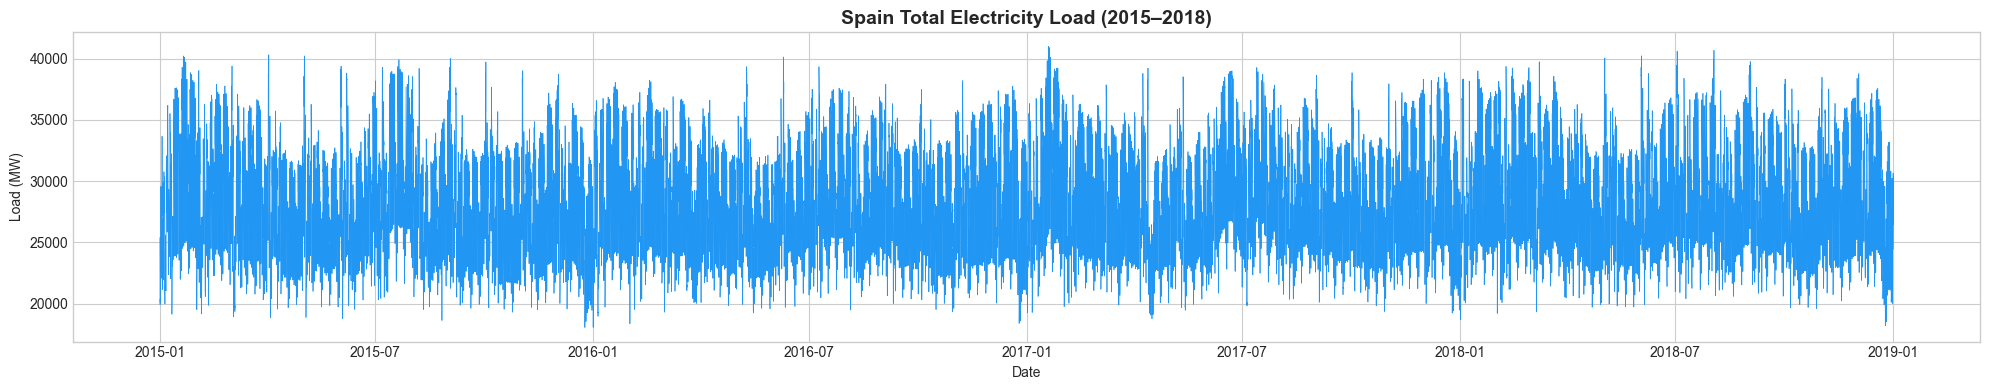


Basic Statistics:


,total load actual
count,35064.0
mean,28697.6
std,4575.9
min,18041.0
25%,24806.8
50%,28902.0
75%,32194.2
max,41015.0


In [5]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df.index, df['total load actual'], linewidth=0.5, color='#2196F3')
ax.set_title('Spain Total Electricity Load (2015\u20132018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:")
display(df.describe().round(1))

## Step 6 — Train / Test Split

**Identical split to Notebooks 1 and 2** so the test set is the same across all three approaches:
- **Context period**: 2015-01-01 → 2017-10-28 (~2.8 years) — used as contextual history but **never for model training**
- **Test set**: 2018-01-01 → end (~1 year)

> **Important distinction:** In zero-shot mode, the "training" data is not used for fitting any model weights. We define the split purely so the test set evaluation window is identical across all three notebooks — this makes the final metric comparison meaningful.

Even though TTM is never trained on our data, when generating a test-set forecast at time t, we supply 1,536 hours of historical context ending at t. For test points early in 2018, this context window reaches back into the 2017 training period — which is entirely fine, since we are only reading history (no model update).

In [6]:
# Chronological split — identical to CatBoost notebooks
df_train = df.loc['2015-01-01':'2017-10-28 00:00:00'].copy()
df_test = df.loc['2018-01-01':].copy()

print(f"Context period: {df_train.shape[0]:,} rows ({df_train.index.min().date()} to {df_train.index.max().date()})")
print(f"Test set:       {df_test.shape[0]:,} rows ({df_test.index.min().date()} to {df_test.index.max().date()})")
print(f"Target:         total load actual")

Context period: 24,745 rows (2015-01-01 to 2017-10-28)
Test set:       8,759 rows (2018-01-01 to 2018-12-31)
Target:         total load actual


## Step 7 — Load the TTM Granite Model

### How HuggingFace `.from_pretrained()` works

The `from_pretrained()` call downloads the model weights from the HuggingFace Hub on first run and caches them locally. On subsequent runs it loads from the cache. This is the same pattern used across the entire HuggingFace ecosystem (BERT, GPT-2, etc.).

### Model configuration for this task

We load the `1536-96-r2` branch of `ibm-granite/granite-timeseries-ttm-r2`. The branch name encodes the two key hyperparameters we care about:
- **1536** — context length (the model expects exactly 1,536 hourly values as input)
- **96** — prediction length (the model outputs exactly 96 values)

These must match our CONTEXT_LENGTH and FORECAST_HORIZON constants, or the model will raise a shape error.

### What `model.eval()` does

Calling `model.eval()` switches PyTorch from training mode (which activates dropout and batch normalisation in training mode) to evaluation/inference mode. This ensures deterministic, consistent predictions. **Always call `.eval()` before inference.**

### Input tensor shape

TTM expects inputs of shape `(batch_size, context_length, n_channels)`. For a single univariate time series:
- `batch_size = 1`
- `context_length = 1536`
- `n_channels = 1`

In [7]:
from tsfm_public import TinyTimeMixerForPrediction

CONTEXT_LENGTH = 1536  # 1536 hours of history as input (~64 days)
FORECAST_HORIZON = 96  # 96 hours = 4 days ahead

# Load pre-trained TTM R2 model from HuggingFace
# Use the "1536-96-r2" branch for context_length=1536, prediction_length=96
model = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2",
    revision="1536-96-r2",
)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"Model loaded: granite-timeseries-ttm-r2 (branch: 1536-96-r2)")
print(f"Context length: {CONTEXT_LENGTH} hours ({CONTEXT_LENGTH/24:.0f} days)")
print(f"Prediction length: {FORECAST_HORIZON} hours ({FORECAST_HORIZON/24:.0f} days)")
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded: granite-timeseries-ttm-r2 (branch: 1536-96-r2)
Context length: 1536 hours (64 days)
Prediction length: 96 hours (4 days)
Device: mps
Parameters: 3,081,120


## Step 8 — Generate Zero-Shot Forecasts

### The per-window normalisation step

Foundation models are trained on diverse time series with very different scales — some in thousands, some in fractions. If we fed raw MW values directly, the model would be outside the distribution it was trained on.

The solution is **per-window normalisation**: for each 1,536-hour context window, subtract its mean and divide by its standard deviation before feeding it to the model. After the model produces its normalised 96-step output, we reverse the transformation (multiply by std, add mean) to recover forecasts in the original MW scale.

```
context_norm = (context − mean) / std         # normalise input
pred_norm    = model(context_norm)             # TTM inference
pred_mw      = (pred_norm × std) + mean        # denormalise output
```

This is a form of *instance normalisation* — different from global normalisation where you compute a single mean/std across all training data. Per-window normalisation is important because it adapts the scale dynamically to the current context, without requiring the model to know anything about typical electricity demand levels.

### Sliding window inference

We slide the 1,536-hour context window forward by one hour at a time across the test set. For each origin:
1. Extract the 1,536 values ending at the current position
2. Normalise, run TTM, denormalise
3. Store the 96 predictions and 96 actuals

This produces the same `forecast_df` format as Notebooks 1 and 2, enabling a direct metric comparison.

In [8]:
feature_name = 'total load actual'

# Combine train + test for context lookback
df_full = pd.concat([df_train, df_test])
values = df_full[feature_name].values.astype(np.float32)

# Build index mapping: for each test timestamp, find its position in df_full
test_start_idx = len(df_train)
n_test = len(df_test)

forecast_rows = []

with torch.no_grad():
    for i in tqdm(range(n_test - FORECAST_HORIZON), desc="Zero-shot forecasting"):
        pos = test_start_idx + i  # Position in df_full
        
        # Need CONTEXT_LENGTH points ending at pos (inclusive)
        ctx_start = pos - CONTEXT_LENGTH + 1
        if ctx_start < 0:
            continue
        
        # Extract context window
        context = values[ctx_start:pos + 1]  # shape: (CONTEXT_LENGTH,)
        
        # Normalize (per-window zero-mean, unit-variance)
        mean_val = np.mean(context)
        std_val = np.std(context)
        if std_val < 1e-8:
            std_val = 1.0
        context_norm = (context - mean_val) / std_val
        
        # Prepare input tensor: (batch=1, context_length, channels=1)
        input_tensor = torch.tensor(context_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        
        # Forward pass
        output = model(input_tensor)
        pred_norm = output.prediction_outputs.squeeze().cpu().numpy()  # shape: (FORECAST_HORIZON,)
        
        # Denormalize
        pred = (pred_norm * std_val) + mean_val
        
        # Actual values for the forecast window
        actual = values[pos + 1:pos + 1 + FORECAST_HORIZON]
        
        if len(actual) == FORECAST_HORIZON:
            timestamp = df_test.index[i]
            forecast_rows.append([timestamp, pred.tolist(), actual.tolist()])

forecast_df = pd.DataFrame(
    forecast_rows,
    columns=['time', feature_name + '_prediction', feature_name]
)
forecast_df.reset_index(drop=True, inplace=True)

print(f"Generated {len(forecast_df):,} forecast windows, each with {FORECAST_HORIZON} steps")

Zero-shot forecasting:   0%|          | 0/8663 [00:00<?, ?it/s]

Generated 8,663 forecast windows, each with 96 steps


## Step 9 — Evaluation Metrics

Same metrics as Notebooks 1 and 2: MAE and RMSE aggregated across all forecast windows and horizons, plus per-horizon MAE.

**What to watch for when comparing with CatBoost:**
- How large is the MAE gap between TTM and CatBoost Direct? Is it surprising given that TTM saw **zero** examples from this dataset?
- Does TTM's per-horizon MAE curve have a different shape than CatBoost's? (CatBoost with direct multi-output should stay relatively flat; TTM may show different horizon-dependent behaviour based on pre-training)
- TTM uses 1,536 hours of continuous context vs. CatBoost's discrete lag offsets. Does the longer context seem to help or hurt?

In [9]:
def compute_metrics(actual_col, prediction_col, label="CatBoost"):
    """
    Compute MSE, RMSE, MAE both as overall averages and per-horizon.
    
    Parameters:
        actual_col: Series of lists (actual values per forecast window)
        prediction_col: Series of lists (predicted values per forecast window)
        label: Name for the results column
    
    Returns:
        avg_metrics: DataFrame with overall MSE, RMSE, MAE
        horizon_metrics: DataFrame with per-horizon MSE, RMSE, MAE
    """
    a = np.asarray(actual_col.tolist())
    p = np.asarray(prediction_col.tolist())

    mask = ~np.any(np.isnan(a), axis=1) & ~np.any(np.isnan(p), axis=1)

    mse = np.mean(np.square(a[mask, :] - p[mask, :]))
    mae = np.mean(np.abs(a[mask, :] - p[mask, :]))

    mse_t = np.mean(np.square(a[mask, :] - p[mask, :]), axis=0)
    mae_t = np.mean(np.abs(a[mask, :] - p[mask, :]), axis=0)

    avg_metrics = pd.DataFrame({
        label: {
            "Mean Squared Error (MSE)": f"{mse:,.1f}",
            "Root Mean Squared Error (RMSE)": f"{np.sqrt(mse):,.1f}",
            "Mean Absolute Error (MAE)": f"{mae:,.1f}",
        }
    })

    horizon_metrics = pd.DataFrame({
        "horizon_hour": np.arange(1, len(mse_t) + 1),
        "mse": mse_t,
        "rmse": np.sqrt(mse_t),
        "mae": mae_t,
    })

    return avg_metrics, horizon_metrics

In [10]:
avg_metrics, horizon_metrics = compute_metrics(
    forecast_df[feature_name],
    forecast_df[feature_name + '_prediction'],
    label="TTM Granite (Zero-Shot)"
)

print("=" * 50)
print("OVERALL METRICS (averaged across all horizons)")
print("=" * 50)
display(avg_metrics)

OVERALL METRICS (averaged across all horizons)


,TTM Granite (Zero-Shot)
Mean Squared Error (MSE),"8,529,328.8"
Root Mean Squared Error (RMSE),"2,920.5"
Mean Absolute Error (MAE),"2,181.5"


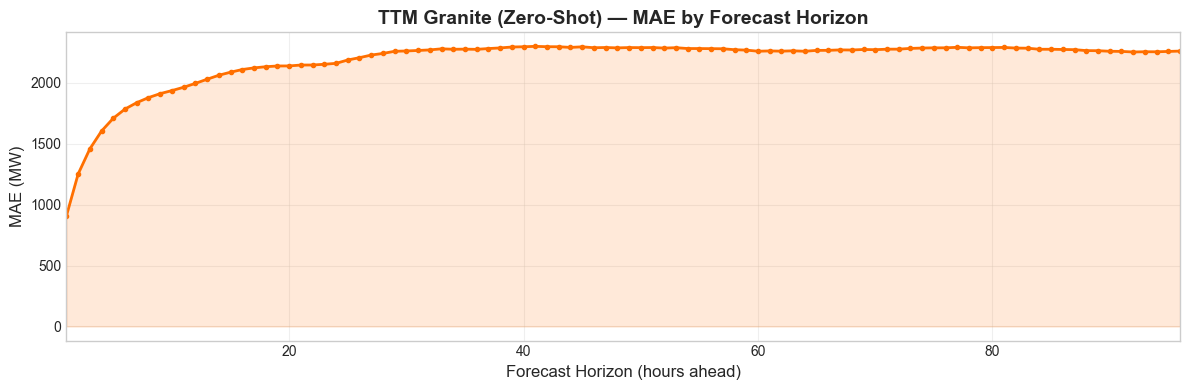

MAE at t+1:  907.9 MW
MAE at t+24: 2,160.6 MW
MAE at t+48: 2,287.5 MW
MAE at t+96: 2,261.4 MW


In [11]:
# Plot MAE by forecast horizon — shows how error grows with prediction distance
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(horizon_metrics['horizon_hour'], horizon_metrics['mae'], 
        color='#FF6F00', linewidth=2, marker='o', markersize=3)
ax.fill_between(horizon_metrics['horizon_hour'], 0, horizon_metrics['mae'], 
                alpha=0.15, color='#FF6F00')
ax.set_xlabel('Forecast Horizon (hours ahead)', fontsize=12)
ax.set_ylabel('MAE (MW)', fontsize=12)
ax.set_title('TTM Granite (Zero-Shot) \u2014 MAE by Forecast Horizon', fontsize=14, fontweight='bold')
ax.set_xlim(1, FORECAST_HORIZON)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAE at t+1:  {horizon_metrics['mae'].iloc[0]:,.1f} MW")
print(f"MAE at t+24: {horizon_metrics['mae'].iloc[23]:,.1f} MW")
print(f"MAE at t+48: {horizon_metrics['mae'].iloc[47]:,.1f} MW")
print(f"MAE at t+96: {horizon_metrics['mae'].iloc[95]:,.1f} MW")

## Step 10 — Forecast Visualization

Same three test window indices as Notebooks 1 and 2 (200, 400, 600) to allow side-by-side visual comparison.

**What to look for vs. CatBoost:**
- Does TTM correctly capture the daily on/off peak cycle even without any training on this data?
- Are there systematic biases (always under- or over-predicting) that CatBoost avoids?
- Where does the TTM forecast look surprisingly good despite zero training? Where does it fail?

In [12]:
def create_timestamps(last_timestamp, freq, periods=1):
    """Generate `periods` timestamps after `last_timestamp` at a given frequency."""
    return pd.date_range(
        start=last_timestamp, freq=freq, periods=periods + 1
    ).tolist()[1:]

In [13]:
def plot_predictions(
    df, predictions_df, freq, timestamp_column, channel, indices, plot_context=None
):
    """
    Plot forecast windows alongside actual values.
    
    Parameters:
        df: DataFrame with actual values and a timestamp column
        predictions_df: DataFrame with 'time', prediction lists, and actual lists
        freq: Frequency string (e.g., 'h' for hourly)
        timestamp_column: Name of the timestamp column in df
        channel: Target column name
        indices: List of row indices from predictions_df to plot
        plot_context: Number of historical points to show before forecast
    """
    pred_col = f"{channel}_prediction"
    predictions_subset = [predictions_df.iloc[i] for i in indices]

    gt_df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(gt_df[timestamp_column]):
        gt_df[timestamp_column] = pd.to_datetime(gt_df[timestamp_column])
    gt_df = gt_df.set_index(timestamp_column)

    prediction_length = len(predictions_subset[0][pred_col])
    if plot_context is None:
        plot_context = 2 * prediction_length

    fig, axs = plt.subplots(len(indices), 1, figsize=(14, 3 * len(indices)), squeeze=False)
    axs = axs.flatten()

    for i, idx in enumerate(indices):
        row = predictions_subset[i]
        origin = pd.to_datetime(row[timestamp_column])
        if gt_df.index.tz is not None and origin.tzinfo is None:
            origin = origin.tz_localize(gt_df.index.tz)
        elif gt_df.index.tz is None and origin.tzinfo is not None:
            origin = origin.tz_localize(None)

        if origin not in gt_df.index:
            axs[i].set_title(f"Window {idx} \u2014 origin not found")
            continue

        loc = gt_df.index.get_loc(origin)
        ctx_start = max(0, loc - plot_context + 1)

        ts_ctx = gt_df.index[ctx_start:loc + 1]
        y_ctx = gt_df.iloc[ctx_start:loc + 1][channel].values

        act_end = min(loc + 1 + prediction_length, len(gt_df))
        ts_act = gt_df.index[loc + 1:act_end]
        y_act = gt_df.iloc[loc + 1:act_end][channel].values

        ts_pred = create_timestamps(origin, freq=freq, periods=prediction_length)
        y_pred = row[pred_col]

        # Plot
        ts_full = ts_ctx.append(ts_act) if len(ts_act) > 0 else ts_ctx
        y_full = np.concatenate([y_ctx, y_act])

        axs[i].plot(ts_full, y_full, label="Actual", color='#2196F3', linewidth=1.5)
        axs[i].plot(ts_pred[:len(y_pred)], y_pred, label="Predicted", 
                    color='#FF6F00', linewidth=1.5, linestyle='--')
        axs[i].axvline(x=origin, color='red', linestyle='-', alpha=0.7, label='Forecast Origin')
        axs[i].set_title(f"Forecast Window {idx} \u2014 Origin: {origin}", fontsize=11)
        axs[i].legend(loc='upper right', fontsize=8)
        axs[i].set_ylabel('Load (MW)')

    plt.tight_layout()
    plt.show()

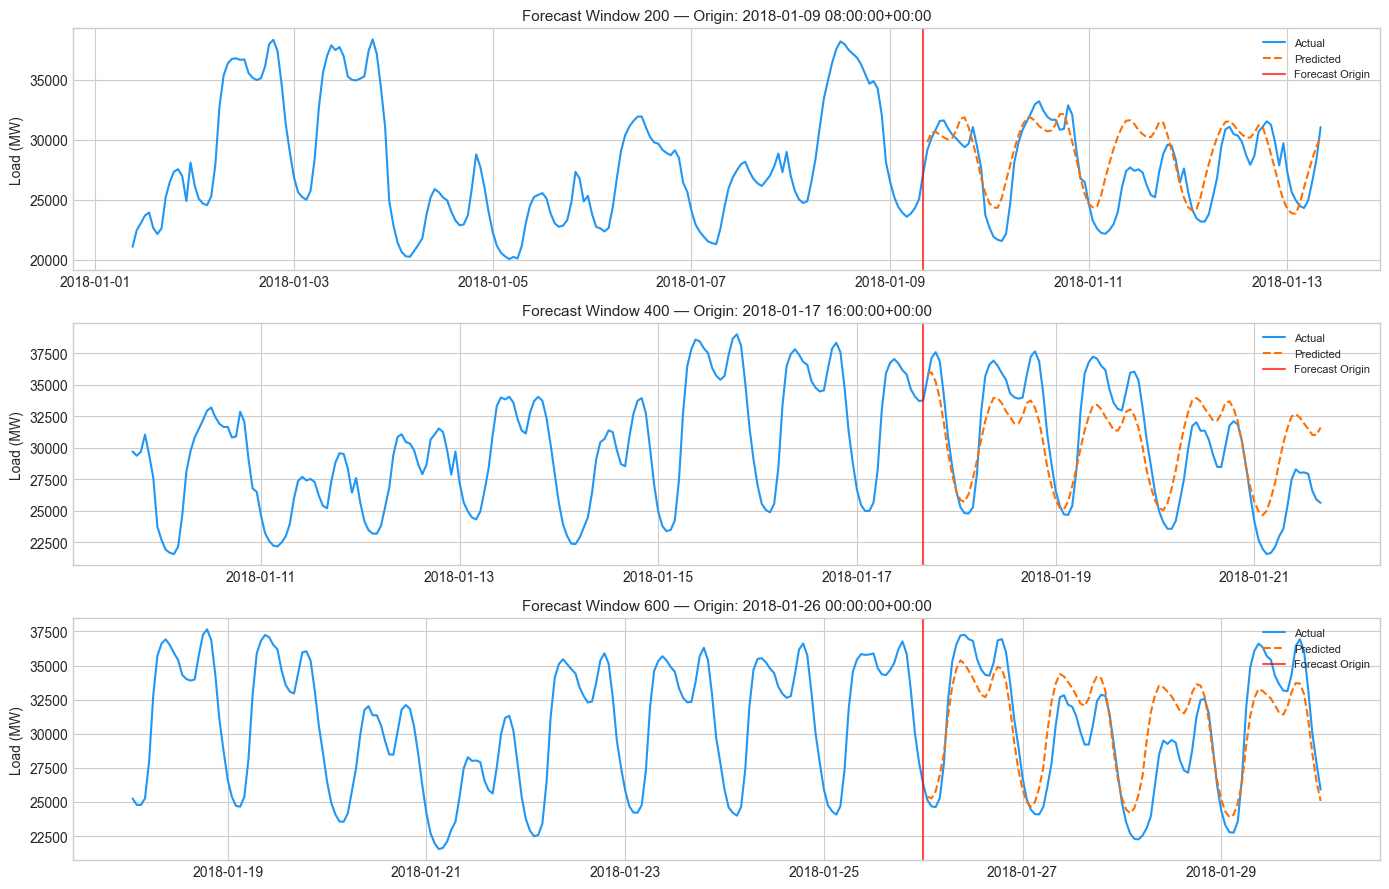

In [14]:
# Prepare test data for plotting
df_test_plot = df_test.copy().reset_index()
df_test_plot.rename(columns={'index': 'time'}, inplace=True)

# Plot 3 example forecast windows
plot_predictions(
    df=df_test_plot,
    predictions_df=forecast_df,
    freq="h",
    timestamp_column="time",
    channel=feature_name,
    indices=[200, 400, 600],
)

## Step 11 — Save Results

Same pickle format as Notebooks 1 and 2. Saving `forecast_df` lets you later load all three result files and build a unified comparison table or chart without re-running the full inference loop.

In [15]:
import pickle

output_path = 'ttm_granite_zeroshot_forecast.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(forecast_df, f)

print(f"Forecast saved to {output_path}")
print(f"Shape: {forecast_df.shape}")

Forecast saved to ttm_granite_zeroshot_forecast.pkl
Shape: (8663, 3)


## Summary & Key Takeaways

### What we did
1. Loaded the same 4-year Spanish electricity dataset as Notebooks 1 and 2 — no extra preprocessing needed for TTM
2. Downloaded IBM's pre-trained TTM Granite R2 model from HuggingFace (zero fine-tuning)
3. Generated 96-step-ahead forecasts using sliding 1,536-hour context windows with per-window normalisation
4. Evaluated with the same metrics and visualisation as CatBoost for a direct comparison

### Three-Notebook Comparison

| Aspect | CatBoost Direct (NB1) | CatBoost Walk-Forward (NB2) | TTM Granite Zero-Shot (NB3) |
|--------|----------------------|----------------------------|-----------------------------|
| Feature engineering | 70+ features | 70+ features | None — raw series |
| Models trained | 96 | 1 | 0 (pre-trained weights) |
| Training time | Minutes | ~1 minute | 0 (inference only) |
| Context style | Discrete lag offsets | Rolling buffers (recursive) | 1,536 continuous hours |
| MAE (approx.) | ~1,381 MW | ~1,758 MW | ~2,182 MW |
| Error accumulation | None | Compounds over 96 steps | None (single forward pass) |

### Key Concepts from This Notebook

| Concept | Explanation |
|---------|------------|
| **Zero-shot inference** | Using a pre-trained model on a new domain without any fine-tuning |
| **Foundation model** | A model pre-trained on large, diverse data that generalises to new tasks without task-specific training |
| **Per-window normalisation** | Scale each input window to zero-mean / unit-variance so the model operates in a consistent range |
| **Context window** | The fixed-length history (1,536 hours here) that the model reads to make its forecast |
| **HuggingFace `from_pretrained()`** | Standard API to download and load pre-trained model weights from the Model Hub |

### Broader Lesson

TTM achieves roughly 58% higher MAE than CatBoost Direct — a meaningful gap. Yet it required **zero** feature engineering and **zero** training time. As foundation models improve and their pre-training becomes more domain-aware, this gap will narrow.

The right question is not "which is better?" but "which trade-offs matter for your use case?":
- **Production system where accuracy is critical**: train a domain-specific model with careful feature engineering
- **Rapid prototyping or cold-start situations with no labelled history**: foundation model zero-shot is a strong starting point

### Discussion questions
1. We used per-window normalisation (instance norm). What would happen if we normalised using global training set statistics instead? Would the model perform better or worse?
2. TTM's context window is 1,536 hours = 64 days. CatBoost's longest lag is 144 hours = 6 days. Does the longer context seem to help TTM, or does it mainly add noise?
3. What is the next step after zero-shot? (Hint: fine-tune only the prediction head while freezing the backbone — this is how `TTM_Granite_Finetuned.ipynb` works.)

---
*Notebook 3 of 3 — You have now seen all three forecasting approaches. Compare the saved `.pkl` files across notebooks to build a unified leaderboard.*